# PS-S06E06: LightGBM

This notebook tackles the [**Playground Series – Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`GALAXY`, `QSO`, `STAR`) for the `class` target, based on features describing the position, light intensity across SDSS photometric bands, redshift, spectral type, and galaxy population for each observed object.

## Introduction

**LightGBM** distinguishes itself with a leaf-wise (best-first) tree growth strategy, contrasting with the level-wise approach used by XGBoost. This allows it to converge faster and often capture more complex, non-linear dependencies. It handles missing values internally and is highly optimized for memory efficiency and training speed. LightGBM has native support for categorical features — `spectral_type` and `galaxy_population` are passed as `category` dtype and handled natively without manual encoding.

This notebook is one of several exploring different models for this challenge. The EDA was performed in: [**PS-S06E06: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e06-eda).

## Install Needed Packages

In [1]:
%pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.exceptions import TrialPruned
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e06_feature_engineering import FeatureFactory
from ps_s06e06_model_visualizer import ModelVisualizer
from ps_s06e06_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

%matplotlib inline

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'class'

# Class label mapping (must be consistent everywhere)
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}

# Use GPU for tree building if available
USE_GPU = True

# Recursive Feature Elimination
PERFORM_RFE = False

# Optuna hyperparameter tuning
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_dataset("training")

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  
0             M      Red_Sequence  GALAXY  
1             M      Red_Sequence  GALAXY  
2           O/B        Blue_Cloud     QSO  
3             M      Red_Sequence  GALAXY  
4             M      Red_Sequence  GALAXY  


## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset("test")

TEST DATASET

       id   alpha  delta      u      g      r      i      z  redshift  \
0  577347 120.720 23.924 23.668 21.952 21.086 20.180 19.202     0.429   
1  577348 219.414 42.172 24.903 22.339 20.732 19.860 19.688     0.867   
2  577349 173.569 -1.756 19.428 18.475 17.551 16.571 16.177     0.224   
3  577350 184.904 -1.411 23.121 21.527 20.670 20.418 20.699     0.067   
4  577351 222.488 15.381 25.094 22.644 21.123 19.440 19.094     0.977   

  spectral_type galaxy_population  
0           G/K      Red_Sequence  
1             M      Red_Sequence  
2           G/K        Blue_Cloud  
3           G/K      Red_Sequence  
4             M      Red_Sequence  


## Feature Engineering

LightGBM handles `category` dtype natively, so `spectral_type` and `galaxy_population` are cast directly without ordinal encoding. The full strategy set mirrors the XGBoost notebook:

- `encoding` — Casts `spectral_type` (ordered O/B→M) and `galaxy_population` to `category` dtype
- `colors` — SDSS photometric colour indices (`u-g`, `g-r`, `r-i`, `i-z`, wider-baseline combos)
- `ratios` — SED shape features: mean/std magnitude, spectral slope, outer-to-central band ratio
- `redshift` — Redshift-derived features and colour×redshift interaction terms
- `position` — Cartesian sky-coordinate projection and |δ|
- `interactions` — Higher-order cross-feature products


In [6]:
# Define which strategies to use for the LightGBM model here:
fe_strategies = [
    'encoding',       # Cast spectral_type and galaxy_population to category dtype
    'colors',         # SDSS photometric colour indices
    'ratios',         # SED shape features: mean/std magnitude, spectral slope
    'redshift',       # Redshift-derived features and colour×redshift interactions
    'position',       # Sky-coordinate Cartesian projection and |delta|
    'interactions',   # Higher-order cross-feature products
]

In [7]:
print('Performing initial feature engineering.')

feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Encode target labels: QSO=0, STAR=1, GALAXY=2
y = training_df[TARGET].map(target_mapping).astype(int)

X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

# Get categorical columns and cast to category dtype for LightGBM native handling
cat_cols = feature_engineer.get_cat_features(X)
cat_cols = [c for c in cat_cols if c in X.columns]

for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 11
New Feature Count: 39
    alpha  delta      u      g      r      i      z  redshift spectral_type  \
0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409             M   
1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158             M   
2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824           O/B   
3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536             M   
4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556             M   

  galaxy_population  u_minus_g  g_minus_r  r_minus_i  i_minus_z  u_minus_r  \
0      Red_Sequence      3.577      1.538      1.101      0.636      5.114   
1      Red_Sequence      1.691      1.500      0.361      0.440      3.191   
2        Blue_Cloud     -0.044     -0.093      0.589      0.025     -0.137   
3      Red_Sequence      2.254      2.033      0.652      0.451      4.287   
4      Red_Sequence      2.231      1.237      0.33

## Recursive Feature Elimination

In [8]:
n_jobs = 1 if USE_GPU else -1

# Prepare a numeric copy for RFECV (requires numeric types)
X_rfe = X.copy()
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes

if PERFORM_RFE:
    clf = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        objective='multiclass',
        num_class=3,
        class_weight='balanced',
        random_state=seed,
        n_jobs=n_jobs,
        importance_type='gain',
        verbosity=-1
    )

    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='balanced_accuracy',
        min_features_to_select=10,
        n_jobs=n_jobs,
        verbose=1
    )

    print('Running Recursive Feature Elimination for LightGBM...')
    rfecv.fit(X_rfe, y)

    print(f'Optimal number of features: {rfecv.n_features_}')

    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (Balanced Accuracy)')
    plt.plot(
        range(rfecv.min_features_to_select,
              len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('LightGBM RFE Results for Stellar Class')
    plt.show()

    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = X_rfe.columns

print('\nOptimal Features Count:', len(optimal_cols))
print('Optimal Features:', optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features Count: 39
Optimal Features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_minus_g', 'g_minus_r', 'r_minus_i', 'i_minus_z', 'u_minus_r', 'u_minus_z', 'g_minus_z', 'g_minus_i', 'color_range', 'blue_red_slope', 'color_curvature', 'mean_mag', 'std_mag', 'outer_to_r', 'redshift_log1p', 'redshift_sq', 'is_near_zero_z', 'is_high_z', 'z_x_u_g', 'z_x_g_r', 'z_x_color_range', 'pos_x', 'pos_y', 'pos_z', 'abs_delta', 'z_x_mean_mag', 'ug_x_gr', 'gr_x_ri', 'std_mag_x_z']


## Optuna Tuning

In [9]:
print("Precomputing fold-wise FE for Optuna (once)...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []

cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    X_train_fold = training_df.iloc[train_idx].copy()
    X_val_fold   = training_df.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold   = y.iloc[val_idx].copy()

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]

    fold_cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    fold_cat_cols = [c for c in fold_cat_cols if c in X_val_trans.columns]

    fold_cache.append((X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx))

print("Cached folds:", len(fold_cache))

Precomputing fold-wise FE for Optuna (once)...
Cached folds: 5


In [10]:
n_jobs = 6

def objective(trial):
    params = {
        'n_estimators': 2000,
        'boosting_type': 'gbdt',
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'None',
        'class_weight': 'balanced',

        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),

        # Leaf-wise growth: num_leaves is the primary complexity control
        # For stellar classification, deeper trees help capture redshift boundaries
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),

        'subsample': trial.suggest_float('subsample', 0.70, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.70, 1.0),

        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        'feature_pre_filter': False,
        'force_col_wise': True,

        'random_state': seed,
        'device_type': 'cpu',  # Forced CPU for Optuna trials
        'n_jobs': n_jobs,
        'verbosity': -1,
    }

    oof_preds = np.zeros(len(y), dtype=int)

    for fold, (X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx) in enumerate(fold_cache):
        for col in fold_cat_cols:
            if col in X_train_trans.columns:
                X_train_trans[col] = X_train_trans[col].astype('category')
                X_val_trans[col]   = X_val_trans[col].astype('category')

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            eval_metric='multi_logloss',
            categorical_feature=fold_cat_cols,
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ]
        )

        preds = model.predict(X_val_trans)
        oof_preds[val_idx] = preds

        del model
        gc.collect()

        fold_score = balanced_accuracy_score(y_val_fold, preds)
        trial.report(fold_score, step=fold)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return balanced_accuracy_score(y, oof_preds)

In [11]:
if PERFORM_OPTUNA_TUNING:
    print('Starting LightGBM Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1
    )

    study_lgbm = optuna.create_study(
        direction='maximize',
        study_name='lgbm_predict_stellar_class_optuna',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True,
        )
    )

    study_lgbm.optimize(
        objective,
        n_trials=25,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )

    print('\nBest Trial:')
    print(f'  Balanced Accuracy: {study_lgbm.best_value:.5f}')
    print('  Params: ', study_lgbm.best_params)

    lgbm_best_params = study_lgbm.best_params
else:
    # Placeholder params — replace with Optuna best_params after first tuning run
    lgbm_best_params = {
        'learning_rate': 0.022460639621576208,
        'num_leaves': 53,
        'max_depth': 7,
        'min_child_samples': 88,
        'subsample': 0.9518987972414449,
        'subsample_freq': 1,
        'colsample_bytree': 0.8317575225741076,
        'reg_alpha': 2.8146747113332005,
        'reg_lambda': 0.016994894789223593
    }

    print('\nUsing placeholder params (run Optuna for tuned values):')
    print('  Params: ', lgbm_best_params)

[I 2026-06-05 16:40:39,751] A new study created in memory with name: lgbm_predict_stellar_class_optuna


Starting LightGBM Optuna Optimization...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-06-05 16:56:07,197] Trial 0 finished with value: 0.9654409896572975 and parameters: {'learning_rate': 0.027602609060648257, 'num_leaves': 33, 'max_depth': 8, 'min_child_samples': 78, 'subsample': 0.7926260670294518, 'subsample_freq': 4, 'colsample_bytree': 0.999163442251491, 'reg_alpha': 0.45624196832363745, 'reg_lambda': 0.1126027727166219}. Best is trial 0 with value: 0.9654409896572975.
[I 2026-06-05 17:13:43,351] Trial 1 finished with value: 0.9657785336495532 and parameters: {'learning_rate': 0.015426717383914814, 'num_leaves': 56, 'max_depth': 6, 'min_child_samples': 57, 'subsample': 0.9102555827583725, 'subsample_freq': 1, 'colsample_bytree': 0.9372094004090716, 'reg_alpha': 0.35382830316192654, 'reg_lambda': 0.05924906068160358}. Best is trial 1 with value: 0.9657785336495532.
[I 2026-06-05 17:28:13,305] Trial 2 finished with value: 0.965471803313198 and parameters: {'learning_rate': 0.01630952768677333, 'num_leaves': 35, 'max_depth': 7, 'min_child_samples': 13, 'subsam

## Model Training

In [12]:
# TARGET MAPPING REFERENCE:
# 0: QSO
# 1: STAR
# 2: GALAXY

lgb_tuned_params = {
    **lgbm_best_params,
    'n_estimators': 20000,
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 3,
    'class_weight': 'balanced',
    'boosting_type': 'gbdt',
    'n_jobs': n_jobs,
    'random_state': seed,
    'device_type': 'gpu' if USE_GPU else 'cpu',
    'verbosity': -1,
}

if lgb_tuned_params['device_type'] == 'gpu':
    lgb_tuned_params['gpu_platform_id'] = 0
    lgb_tuned_params['gpu_device_id'] = 0

print('Final LightGBM CV Training with OOF / Test probabilities')
print('======================================================')
print('Parameters used for training:')
print(lgb_tuned_params)
print(' ')

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

eval_results = []
models = []

oof_probs = np.zeros((len(y), 3))
test_probs = np.zeros((len(test_df), 3))
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    print(f'\nStarting processing of fold {fold+1}')

    X_train_fold = training_df.iloc[train_idx]
    X_val_fold   = training_df.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)
    X_test_trans  = fe.transform(test_df)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    fold_cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    fold_cat_cols = [c for c in fold_cat_cols if c in X_val_trans.columns]

    for col in fold_cat_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')
        X_test_trans[col]  = X_test_trans[col].astype('category')

    model = lgb.LGBMClassifier(**lgb_tuned_params)
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        categorical_feature=fold_cat_cols,
        callbacks=[
            lgb.early_stopping(200, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    eval_results.append(model.evals_result_)
    models.append(model)

    probs = model.predict_proba(X_val_trans)
    preds = np.argmax(probs, axis=1)

    oof_probs[val_idx] = probs
    oof_preds[val_idx] = preds

    fold_score = balanced_accuracy_score(y_val_fold, preds)
    print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')

    test_probs += model.predict_proba(X_test_trans) / n_folds

    del model
    gc.collect()

overall_score = balanced_accuracy_score(y, oof_preds)
print(f'\nOverall CV Balanced Accuracy: {overall_score:.5f}')


Final LightGBM CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.022460639621576208, 'num_leaves': 53, 'max_depth': 7, 'min_child_samples': 88, 'subsample': 0.9518987972414449, 'subsample_freq': 1, 'colsample_bytree': 0.8317575225741076, 'reg_alpha': 2.8146747113332005, 'reg_lambda': 0.016994894789223593, 'n_estimators': 20000, 'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 3, 'class_weight': 'balanced', 'boosting_type': 'gbdt', 'n_jobs': 6, 'random_state': 10301, 'device_type': 'gpu', 'verbosity': -1, 'gpu_platform_id': 0, 'gpu_device_id': 0}
 

Starting processing of fold 1


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[200]	training's multi_logloss: 0.110967	valid_1's multi_logloss: 0.134956
[400]	training's multi_logloss: 0.0932976	valid_1's multi_logloss: 0.118216
[600]	training's multi_logloss: 0.0840037	valid_1's multi_logloss: 0.11178
[800]	training's multi_logloss: 0.0772539	valid_1's multi_logloss: 0.108506
[1000]	training's multi_logloss: 0.0717286	valid_1's multi_logloss: 0.106337
[1200]	training's multi_logloss: 0.0671077	valid_1's multi_logloss: 0.104689
[1400]	training's multi_logloss: 0.0630635	valid_1's multi_logloss: 0.103406
[1600]	training's multi_logloss: 0.0594778	valid_1's multi_logloss: 0.102365
[1800]	training's multi_logloss: 0.0563214	valid_1's multi_logloss: 0.101468
[2000]	training's multi_logloss: 0.053427	valid_1's multi_logloss: 0.100708
[2200]	training's multi_logloss: 0.0507877	valid_1's multi_logloss: 0.0999805
[2400]	training's multi_logloss: 0.0483648	valid_1's multi_logloss: 0.0993997
[2600]	training's multi_logloss: 0.046113	valid_1's multi_logloss: 0.0988979
[280

### Learning Curves (Train vs. Validation Log-Loss)
Tracks `multi_logloss` over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Early stopping terminates training once the validation loss plateaus.

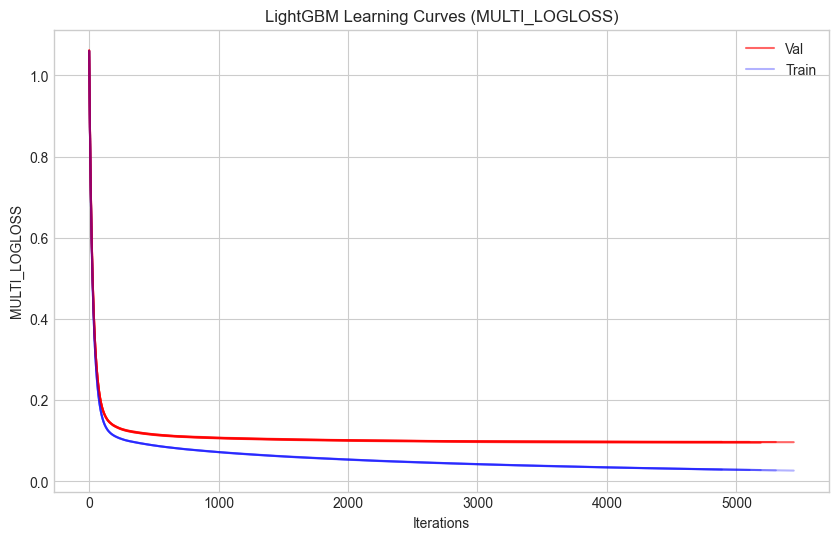

In [13]:
mviz = ModelVisualizer(model_name='LightGBM')

mviz.plot_learning_curves(eval_results, metric='multi_logloss')

### Feature Importance (Gain)

Ranks features by how much they reduced the loss function when used in a split.

* **Validation check:** `redshift`, `redshift_sq`, `redshift_log1p`, and `is_high_z` should dominate — redshift is the single strongest discriminator in SDSS stellar classification.
* **Colour check:** Colour indices (`g_minus_z`, `u_minus_r`, etc.) should rank in the mid-tier. If raw magnitudes outrank colours, verify the `colors` strategy is active.
* **Leakage check:** `id` must not appear. `alpha` and `delta` should rank near zero unless the `position` strategy is active.
* **Zero-importance features:** If any engineered features sit at zero across all folds, they failed to add signal and should be dropped from `fe_strategies` or removed from the `FeatureFactory`.

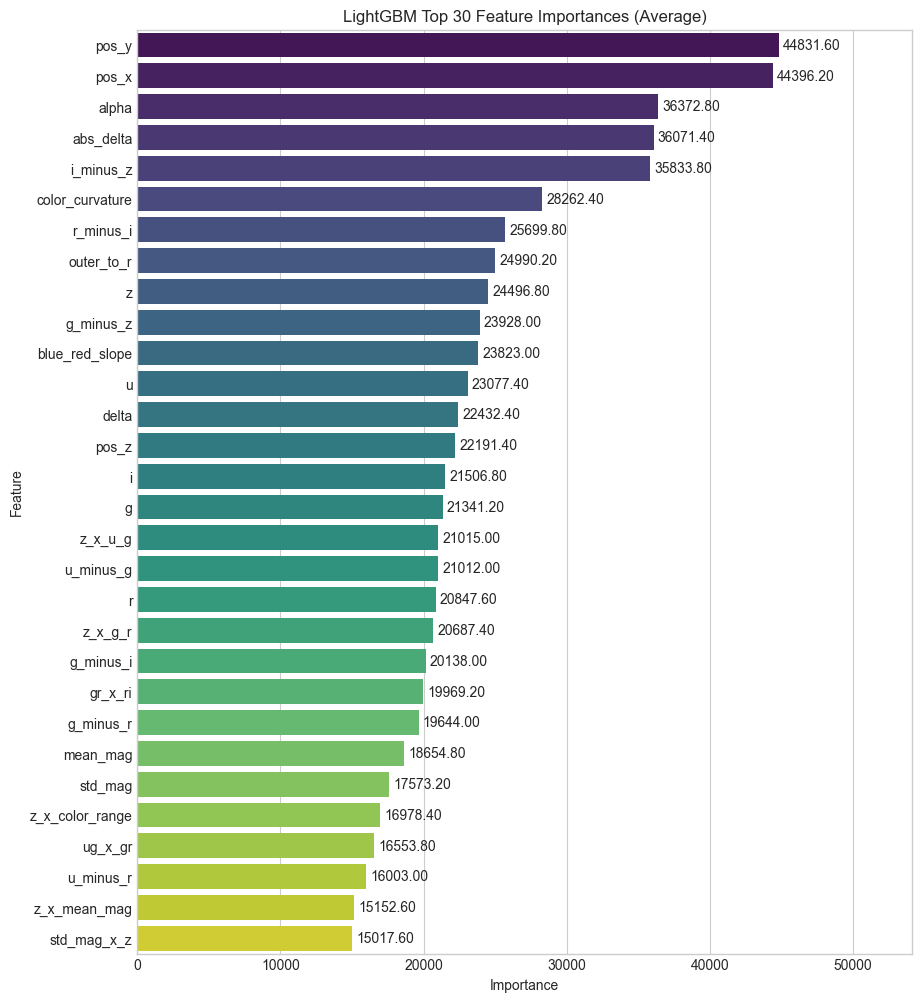

In [14]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (QSO=0, STAR=1, GALAXY=2). A large divergence on one class suggests the model is systematically misclassifying that stellar type.

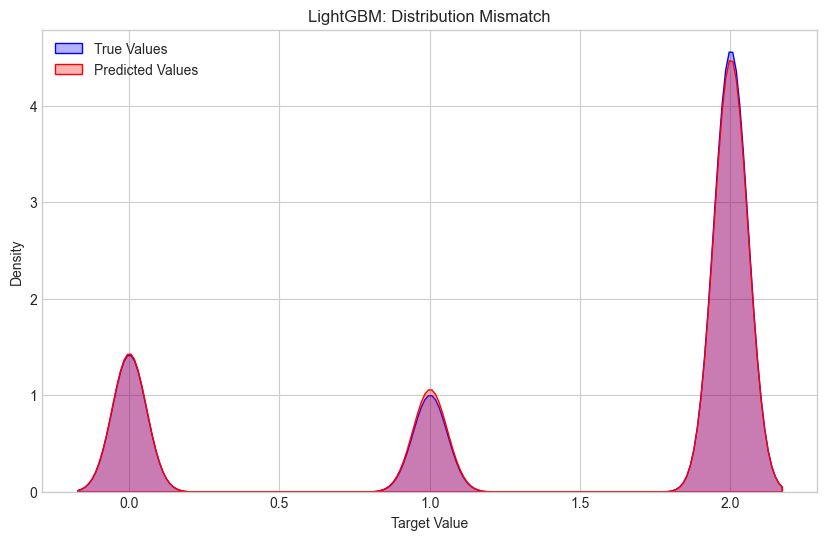

In [15]:
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

### ROC Curves (One-vs-Rest)
Each class is treated as the positive class in turn. AUC measures separation from the other two classes. All three curves should sit well above the diagonal; a sagging QSO curve is the most common weak point in stellar classification tasks.

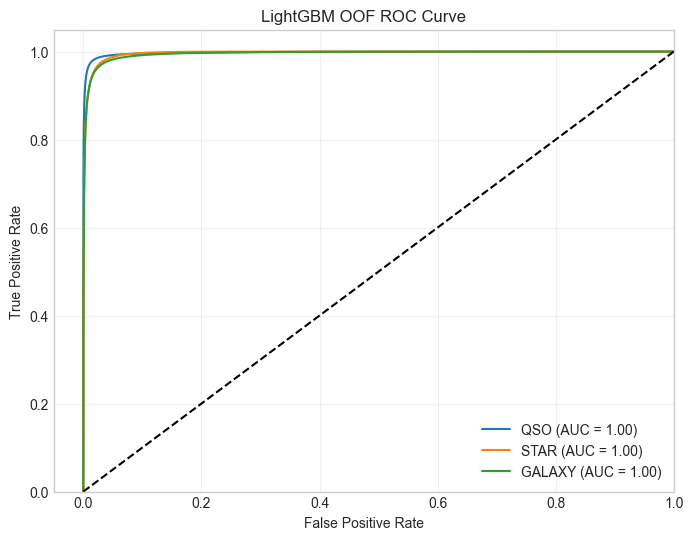

In [16]:
mviz.plot_multiclass_roc_curve(y_true=y, y_score=oof_probs, title='LightGBM OOF ROC Curve')

Normalized confusion matrix


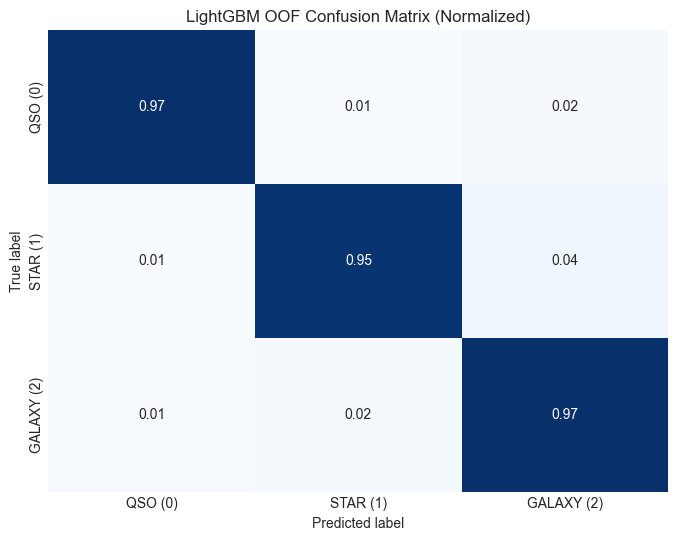

In [17]:
mviz.plot_confusion_matrix(
    y_true=y,
    y_pred=oof_preds,
    classes=['QSO (0)', 'STAR (1)', 'GALAXY (2)'],
    normalize=True,
    title='LightGBM OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires the hard predicted class label (`GALAXY`, `QSO`, or `STAR`) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [18]:
submission_df = helper.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))


SAMPLE SUBMISSION


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [19]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

OOF and averaged test-set probabilities are saved for downstream ensembling (blending or stacking). For this three-class task we save the full probability distribution across `QSO`, `STAR`, and `GALAXY` rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

For blending reference see Tilii's excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [20]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: QSO=0, STAR=1, GALAXY=2
prob_cols = ['prob_qso', 'prob_star', 'prob_galaxy']

# OOF probabilities
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_df = pd.concat([
    pd.DataFrame({'id': training_df['id'].values, 'target': y.values}),
    oof_prob_df
], axis=1)
oof_df.to_csv(f'{output_dir}/lgb_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_df['id'].values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/lgb_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/lgb_oof_probs.csv\n - {output_dir}/lgb_test_probs.csv')


Saved for ensembling:
 - predictions/lgb_oof_probs.csv
 - predictions/lgb_test_probs.csv
